Processed data is stored in pkl file<br>
Load data and fit with PyMC<br>
Pt100 KOH CO oxidation<br>

# Initialization - Rate only

In [1]:
import numpy as np
import pymc as pm
import arviz as az
import pandas as pd
import xarray as xr
import pickle
import nutpie
import matplotlib.pyplot as plt
import pytensor.tensor as pt
import pytensor

pd.set_option('display.max_columns', None); pd.set_option('display.width', 1000); pd.set_option('display.max_colwidth', None)
pd.options.mode.string_storage = "python"; pd.options.future.infer_string = False

plot_target = 'word'

# Experimental conditions and constants 
C_KOH_list = np.array([0.1, 0.25, 0.5, 1]) # in M 
P_CO_list = 0.01*np.array([0.1, 1, 10, 100]) # in atm
R, T, F = 8.3145, 293.15, 96485
kb_eV, h, kb_J = 8.617e-5, 6.626e-34, 1.3806e-23  # eV/K, J.s, J/K

# Load and parse data
with open('Pt100_KOH_replicates.pkl', 'rb') as f:
    experiments_interp = pickle.load(f)

E_in = np.concatenate([experiments_interp[(C, P)]['E'] for C in C_KOH_list for P in P_CO_list])
C_KOH_in = np.concatenate([np.full_like(experiments_interp[(C, P)]['E'], C) for C in C_KOH_list for P in P_CO_list])
P_CO_in = np.concatenate([np.full_like(experiments_interp[(C, P)]['E'], P) for C in C_KOH_list for P in P_CO_list])
log_rate_obs = np.concatenate([experiments_interp[(C, P)]['log_rate'] for C in C_KOH_list for P in P_CO_list])
log_rate_obs_SD = np.concatenate([experiments_interp[(C, P)]['log_rate_SD'] for C in C_KOH_list for P in P_CO_list])

def add_post_sampling_observables(trace):
    """Calculate rate, alpha, delta_OH and delta_CO after sampling."""
    trace.posterior['rate_linear'] = np.exp(trace.posterior['log_rate_model'])

    # 2. Calculate alpha
    log_rate_samples = trace.posterior['log_rate_model'].values
    alpha_samples = np.zeros_like(log_rate_samples)
    model_log_rates = {}
    start = 0
    for C in C_KOH_list:
        for P in P_CO_list:
            E_arr = experiments_interp[(C, P)]['E']
            end = start + len(E_arr)
            alpha_samples[:, :, start:end] = (R * T / F) * np.gradient(log_rate_samples[:, :, start:end], E_arr[1] - E_arr[0], axis=2)
            model_log_rates[(C, P)] = log_rate_samples[:, :, start:end]
            start = end
    trace.posterior['alpha'] = (trace.posterior['log_rate_model'].dims, alpha_samples)
    
    # 3. Calculate delta_OH
    delta_OH_list = []
    ln_C = np.log(C_KOH_list)
    w_C = ((ln_C - np.mean(ln_C)) / np.sum((ln_C - np.mean(ln_C))**2))[None, None, :, None]
    for P in P_CO_list:
        E_arrays = [np.round(experiments_interp[(C, P)]['E'], 6) for C in C_KOH_list]
        common_E = E_arrays[0]
        for arr in E_arrays[1:]: common_E = np.intersect1d(common_E, arr)   
        rates_for_fit = []
        for C in C_KOH_list:
            E_arr = np.round(experiments_interp[(C, P)]['E'], 6)
            mask = np.isin(E_arr, common_E)
            rates_for_fit.append(model_log_rates[(C, P)][:, :, mask])    
        rates_for_fit = np.stack(rates_for_fit, axis=2)
        delta_OH = np.sum(w_C * rates_for_fit, axis=2)
        delta_OH_list.append(delta_OH)
    trace.posterior['delta_OH_model'] = (("chain", "draw", "delta_OH_flat"), np.concatenate(delta_OH_list, axis=2))
    
    # 4. Calculate delta_CO
    delta_CO_list = []
    for C in C_KOH_list:
        for i in range(len(P_CO_list) - 1):
            P1, P2 = P_CO_list[i], P_CO_list[i+1]
            E1 = np.round(experiments_interp[(C, P1)]['E'], 6)
            E2 = np.round(experiments_interp[(C, P2)]['E'], 6)
            common_E = np.intersect1d(E1, E2)
            mask1 = np.isin(E1, common_E); mask2 = np.isin(E2, common_E)
            lr1 = model_log_rates[(C, P1)][:, :, mask1]
            lr2 = model_log_rates[(C, P2)][:, :, mask2]
            delta_CO = (lr2 - lr1) / np.log(P2 / P1)
            delta_CO_list.append(delta_CO)       
    trace.posterior['delta_CO_model'] = (("chain", "draw", "delta_CO_flat"), np.concatenate(delta_CO_list, axis=2))
    
    return trace

def calculate_flattened_r2(ppc, var_name):
    y_true = ppc.observed_data[var_name].values
    y_pred = ppc.posterior_predictive[var_name].values
    chains, draws, N = y_pred.shape
    y_pred_flat = y_pred.reshape(chains * draws, N)
    return az.r2_score(y_true, y_pred_flat)['r2']

In [2]:
def plot_posteriors(trace, model, target='word'): 

    all_vars = list(trace.posterior.data_vars)
    excluded_vars = ['alpha', 'delta_OH_model', 'delta_CO_model', 'rate_linear', 'log_rate', 'log_rate_model']
    var_names = [v for v in all_vars if not v.endswith("__")]
    kinetic_vars = [v for v in var_names if not v.startswith('theta') and v not in excluded_vars]
    summary = az.summary(trace, var_names=kinetic_vars)
    print(summary)
    
    num_vars = len(kinetic_vars)
    cols = min(4, max(1, num_vars)) 
    rows = int(np.ceil(num_vars / cols)) 
    if target == 'ppt':
        rc_update = {'font.size': 14, 'axes.linewidth': 1.5, 'lines.linewidth': 2}
        figsize_post = (3.0 * cols, 3.5 * rows) 
        title_size = 20; text_size_adj = 12 
    else:
        rc_update = {'font.size': 10, 'axes.linewidth': 1, 'lines.linewidth': 1.5}
        figsize_post = (2.5 * cols, 3.0 * rows) 
        title_size = 14; text_size_adj = 10

    # Use a context manager so we don't permanently alter or break notebook plotting behavior
    with plt.rc_context(rc_update):
        if kinetic_vars:
            axes = az.plot_posterior(trace, var_names=kinetic_vars, hdi_prob=0.95, round_to=3, figsize=figsize_post, grid=(rows, cols), textsize=text_size_adj)
            axes_flat = np.array(axes).flatten() 
            for ax in axes_flat: 
                if ax is not None and hasattr(ax, 'texts'):
                    for text_obj in ax.texts: 
                        if 'mean' in text_obj.get_text(): text_obj.set_fontweight('bold')
                    ax.title.set_fontweight('bold')     
            plt.subplots_adjust(hspace=0.5, wspace=0.3, top=0.88); plt.show()
        if len(kinetic_vars) > 1:
            az.plot_pair(trace, var_names=kinetic_vars, kind='kde', divergences=True, figsize=(8,8), textsize=10); plt.show()

    with model: ppc = pm.sample_posterior_predictive(trace, progressbar=False)
    for var_name in ppc.observed_data.data_vars:
        r2 = calculate_flattened_r2(ppc, var_name)
        print(f"{var_name}: {r2:.3f}")
      
    return ppc

def plot_model_fits(trace, ppc, target='word'):

    if target == 'ppt':
        plt.rcParams.update({'font.size': 14, 'axes.linewidth': 1.5, 'lines.linewidth': 2.5})
        figsize_4x4 = (12, 11); figsize_3x4 = (12, 8.5); figsize_1x4 = (12, 4)   
        title_size, label_size = 18, 14
    else:
        plt.rcParams.update({'font.size': 10, 'axes.linewidth': 1, 'lines.linewidth': 2})
        figsize_4x4 = (7.5, 7); figsize_3x4 = (7.5, 5.5); figsize_1x4 = (7.5, 2.5)
        title_size, label_size = 12, 10
    colors = plt.cm.tab10.colors[:len(P_CO_list)]
    
    # 95% CI multiplier for the mean with n=4 replicates (df=3, t=3.182)
    ci_multiplier = 3.182 / np.sqrt(4) 

    def get_model_slice(var_track, C_KOH, P_CO, is_ppc=False):
        dataset = ppc.posterior_predictive if is_ppc else trace.posterior
        if var_track in ['log_rate_model', 'rate_linear', 'alpha'] or is_ppc:
            idx = 0
            for C in C_KOH_list:
                for P in P_CO_list:
                    length = len(experiments_interp[(C, P)]['E'])
                    if C == C_KOH and P == P_CO:
                        return dataset[var_track if not is_ppc else 'rate'][:, :, idx:idx+length], experiments_interp[(C, P)]['E']
                    idx += length
        elif var_track == 'delta_OH_model':
            idx = 0
            for P in P_CO_list:
                E_arrays = [np.round(experiments_interp[(C, P)]['E'], 6) for C in C_KOH_list]
                common_E = E_arrays[0]
                for arr in E_arrays[1:]: common_E = np.intersect1d(common_E, arr)
                length = len(common_E)
                if P == P_CO: return dataset[var_track][:, :, idx:idx+length], common_E
                idx += length
        elif var_track == 'delta_CO_model':
            idx = 0
            for C in C_KOH_list:
                for i in range(len(P_CO_list)-1):
                    P1, P2 = P_CO_list[i], P_CO_list[i+1]
                    E1 = np.round(experiments_interp[(C, P1)]['E'], 6)
                    E2 = np.round(experiments_interp[(C, P2)]['E'], 6)
                    common_E = np.intersect1d(E1, E2)
                    length = len(common_E)
                    if C == C_KOH and P1 == P_CO: return dataset[var_track][:, :, idx:idx+length], common_E
                    idx += length

    def plot_grid(var_fit, var_track, nrows, ncols, figsize, ylabel, title_text, is_3x4=False, is_1x4=False):
        is_ppc = (var_fit in ppc.posterior_predictive.data_vars)
        share_y = False if var_fit == 'rate_linear' else True
        fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize, sharex='col', sharey=share_y)
        fig.suptitle(title_text, fontsize=title_size, fontweight='bold', y=0.96) # Adjusted y down slightly
        fig.supxlabel(r"E (V$_{\mathbf{SHE}}$)", fontweight='bold', fontsize=label_size + 2)
        fig.supylabel(ylabel, fontweight='bold', fontsize=label_size + 2)

        for i, C_KOH in enumerate(C_KOH_list):
            for j, P_CO in enumerate(P_CO_list):
                if is_1x4 and i > 0: continue
                if is_3x4 and j >= 3: continue

                if is_1x4:
                    ax = axes[j]
                    cond_key = (C_KOH_list[1], P_CO) 
                    exp_mean = experiments_interp[cond_key]['untruncated_delta_OH']
                    exp_sd = experiments_interp[cond_key]['untruncated_delta_OH_SD']
                    E_exp = experiments_interp[cond_key]['untruncated_E_OH']
                    model_slice, E_model = get_model_slice(var_track, None, P_CO, is_ppc)
                elif is_3x4:
                    ax = axes[j, i]
                    cond_key = (C_KOH, P_CO)
                    exp_mean = experiments_interp[cond_key]['untruncated_delta_CO']
                    exp_sd = experiments_interp[cond_key]['untruncated_delta_CO_SD']
                    E_exp = experiments_interp[cond_key]['untruncated_E_CO']
                    model_slice, E_model = get_model_slice(var_track, C_KOH, P_CO, is_ppc)
                else:
                    ax = axes[j, i]
                    cond_key = (C_KOH, P_CO)
                    if var_fit == 'alpha':
                        exp_mean = experiments_interp[cond_key]['untruncated_alpha']
                        exp_sd = experiments_interp[cond_key]['untruncated_alpha_SD']
                        E_exp = experiments_interp[cond_key]['untruncated_E']
                    elif var_fit == 'rate': # The actual fitted log_rate (TRUNCATED)
                        exp_mean = experiments_interp[cond_key]['log_rate']
                        exp_sd = experiments_interp[cond_key]['log_rate_SD']
                        E_exp = experiments_interp[cond_key]['E']
                    elif var_fit == 'rate_linear': # UNTRUNCATED
                        exp_mean = experiments_interp[cond_key]['untruncated_rate']
                        exp_sd = experiments_interp[cond_key]['untruncated_rate_SD']
                        E_exp = experiments_interp[cond_key]['untruncated_E']    
                    model_slice, E_model = get_model_slice(var_track, C_KOH, P_CO, is_ppc)

                model_mean = model_slice.mean(dim=("chain", "draw"))
                hdi_95 = az.hdi(model_slice, hdi_prob=0.95)[model_slice.name]
                hdi_90 = az.hdi(model_slice, hdi_prob=0.90)[model_slice.name]

                # 1. Experimental Data Handling
                if var_fit != 'rate': 
                    exp_ci = exp_sd * ci_multiplier
                    ax.fill_between(E_exp, exp_mean - exp_ci, exp_mean + exp_ci, color='gray', alpha=0.3, linewidth=0, zorder=1)
                # Plot the experimental mean line for everything
                ax.plot(E_exp, exp_mean, color='black', lw=2.5, alpha=0.6, zorder=2)

                # 2. Model Data Handling (HDI shading is plotted over the truncated Nernstian bounds)
                ax.fill_between(E_model, hdi_95[:, 0].values, hdi_95[:, 1].values, color=colors[j], alpha=0.15, linewidth=0, zorder=3)
                ax.fill_between(E_model, hdi_90[:, 0].values, hdi_90[:, 1].values, color=colors[j], alpha=0.30, linewidth=0, zorder=4)
                ax.plot(E_model, model_mean, color=colors[j], lw=3.2, zorder=5)
                if j == 0 and not is_1x4: ax.set_title(f'{C_KOH} M KOH', fontsize=label_size, fontweight='bold')
                if is_1x4: ax.set_title(f'{P_CO} atm', fontsize=label_size, fontweight='bold')
                if i == 3 and not is_1x4:
                    label_right = f'{P_CO} atm' if not is_3x4 else f'{P_CO_list[j]} - {P_CO_list[j+1]} atm'
                    ax.text(1.05, 0.5, label_right, transform=ax.transAxes, rotation=-90, va='center', fontsize=label_size, fontweight='bold')

        bottom_adj = 0.08
        if is_1x4: top_adj = 0.80; bottom_adj = 0.2
        elif var_fit == 'rate_linear': top_adj = 0.88
        elif is_3x4: top_adj = 0.88; bottom_adj = 0.10
        else: top_adj = 0.90
        plt.tight_layout(); plt.subplots_adjust(right=0.92, top=top_adj, left=0.10, bottom=bottom_adj); plt.show()

    plot_grid('rate', 'log_rate_model', 4, 4, figsize_4x4, "log Rate", "Log Rate")
    plot_grid('rate_linear', 'rate_linear', 4, 4, figsize_4x4, "Rate", "Rate")
    plot_grid('alpha', 'alpha', 4, 4, figsize_4x4, "alpha", "Transfer Coefficients")
    plot_grid('delta_OH', 'delta_OH_model', 1, 4, figsize_1x4, "Order (OH)", "OH Reaction Order", is_1x4=True)
    plot_grid('delta_CO', 'delta_CO_model', 3, 4, figsize_3x4, "Order (CO)", "CO Reaction Order", is_3x4=True)
    plt.rcParams.update(plt.rcParamsDefault)

def plot_coverages(trace, target='word'):
    if target == 'ppt':
        plt.rcParams.update({'font.size': 14, 'axes.linewidth': 1.5, 'lines.linewidth': 2.5})
        figsize = (12, 11) 
        title_size, label_size = 20, 16
    else:
        plt.rcParams.update({'font.size': 10, 'axes.linewidth': 1, 'lines.linewidth': 2})
        figsize = (7.5, 6.5)
        title_size, label_size = 12, 10

    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=figsize, sharex='col', sharey=True)    
    fig.suptitle('Modeled Surface Coverages', fontsize=title_size, fontweight='bold', y=0.97)
    fig.supxlabel(r"E (V$_{\mathbf{SHE}}$)", fontweight='bold', fontsize=label_size+2)
    fig.supylabel("Coverage", fontweight='bold', fontsize=label_size+2)

    for i, C_KOH in enumerate(C_KOH_list):
        for j, P_CO in enumerate(P_CO_list):
            ax = axes[j, i]
            E_exp = experiments_interp[(C_KOH, P_CO)]['E']

            for var, col, lab in zip(['theta_CO', 'theta_OH', 'theta_COOH'], 
                                     ['tab:red', 'tab:blue', 'tab:green'], 
                                     [r'$\theta_{CO}$', r'$\theta_{OH}$', r'$\theta_{COOH}$']):
                if var in trace.posterior:
                    idx = 0
                    for C in C_KOH_list:
                        for P in P_CO_list:
                            length = len(experiments_interp[(C, P)]['E'])
                            if C == C_KOH and P == P_CO:
                                data = trace.posterior[var][:, :, idx:idx+length]
                            idx += length
                            
                    mu = data.mean(dim=("chain", "draw"))
                    hdi = az.hdi(data, hdi_prob=0.95)[var]
                    ax.fill_between(E_exp, hdi[:, 0], hdi[:, 1], color=col, alpha=0.15, linewidth=0)
                    ax.plot(E_exp, mu, color=col, label=lab, lw=2.5)

            ax.set_ylim(-0.05, 1.05)
            if j == 0: ax.set_title(f'{C_KOH} M KOH', fontsize=label_size, fontweight='bold')
            if i == 3: ax.text(1.05, 0.5, f'{P_CO} atm', transform=ax.transAxes, rotation=-90, va='center', fontsize=label_size, fontweight='bold')
            if i == 0 and j == 0: ax.legend(loc='best', frameon=False, fontsize=10)

    plt.tight_layout()
    plt.subplots_adjust(right=0.92, top=0.90, bottom=0.08, left=0.10) 
    plt.show()
    plt.rcParams.update(plt.rcParamsDefault)

In [3]:
def fit_and_evaluate(model, draws=1000, tune=2000, chains=4, cores=4, init_mean=None, target_accept=0.9):
    compiled_model = nutpie.compile_pymc_model(model)
    trace = nutpie.sample(compiled_model, draws=draws, tune=tune, chains=chains, cores=cores, init_mean=init_mean, target_accept=target_accept)
    pm.compute_log_likelihood(trace, progressbar=False, model=model)
    loo = az.loo(trace, pointwise=True)
    print(loo); az.plot_khat(loo)
    plt.title("Pareto k diagnostic (Global Model)"); plt.show()
    trace = add_post_sampling_observables(trace)
    return trace, loo

def observables(log_rate_model):
    pm.Deterministic('log_rate_model', log_rate_model)
    log_rate = pm.StudentT('rate', nu=3, mu=log_rate_model, sigma=log_rate_obs_SD, observed=log_rate_obs)
    return log_rate

# ER LH 2 3

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.11,95
,3000,0,0.11,63
,3000,0,0.12,63
,3000,0,0.12,95


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -529.72    38.35
p_loo       16.86        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      494  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



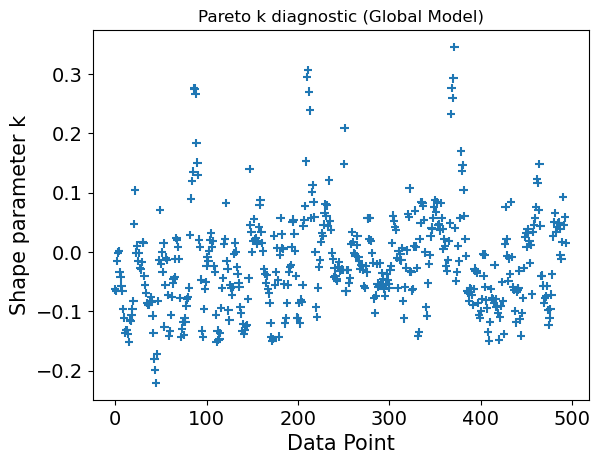

In [6]:
with pm.Model() as ER_LH_2_3:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH- <-> COOH* + (e-) (SSA)
    2b. CO* + OH* <-> COOH* + * (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (SSA)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.TruncatedNormal('deltaG1_0', mu=-0.12, sigma=0.01, upper=0.0)
    deltaG4_0 = pm.TruncatedNormal('deltaG4_0', mu=0.0, sigma=0.05, upper=0.25) 
    deltaG2_ER_0 = pm.Normal('deltaG2_ER_0', mu=-0.45, sigma=0.05) 
    beta_2 = pm.Beta('beta_2', alpha=50.0, beta=150.0)
    beta_3 = pm.Beta('beta_3', alpha=20.0, beta=20.0)
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.74, sigma=0.005) 
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.76, sigma=0.005) 
    Gact3_0 = pm.TruncatedNormal('Gact3_0', mu=0.65, sigma=0.05, lower=0.0) 

    # Thermodynamics 
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG2_ER = deltaG2_ER_0 - E_in
    deltaG2_LH = deltaG2_ER_0 - deltaG4_0 # Hess's law
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact2_LH = Gact2_LH_0 
    Gact3 = Gact3_0 - beta_3*E_in

    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K2_ER = -deltaG2_ER/(kb_eV*T)
    log_K2_LH = -deltaG2_LH/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2_ER/(kb_eV*T)
    log_k2_LH = np.log(kb_J*T/h) - Gact2_LH/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)

    term_CO = log_K1 + np.log(P_CO_in)
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    # Quadratic solver setup
    log_N_ER = log_k2_ER + term_CO + np.log(C_KOH_in)
    log_N_LH = log_k2_LH + term_CO + term_OH
    log_D1 = pt.logaddexp(log_k2_ER - log_K2_ER, log_k3 + np.log(C_KOH_in))
    log_D2 = log_k2_LH - log_K2_LH
    log_S_base = pt.logsumexp(pt.stack([zeros, term_CO, term_OH]), axis=0)
    a_quad = pt.exp(log_D1)
    b_quad = pt.exp(log_D1 + log_S_base) + pt.exp(log_D2) - pt.exp(log_N_ER)
    c_quad = -(pt.exp(log_N_ER + log_S_base) + pt.exp(log_N_LH))
    term_COOH = pt.log((-b_quad + pt.sqrt(b_quad**2 - 4*a_quad*c_quad)) / (2*a_quad))

    log_theta = - pt.logsumexp(pt.stack([zeros, term_CO, term_OH, term_COOH]), axis=0)
    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    log_theta_COOH = term_COOH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_COOH = pm.Deterministic('theta_COOH', pt.exp(log_theta_COOH))

    # Rate expression
    log_rate_model = log_k3 + log_theta_COOH + np.log(C_KOH_in)
    log_rate = observables(log_rate_model)

trace_ER_LH_2_3, loo_ER_LH_2_3 = fit_and_evaluate(ER_LH_2_3, target_accept=0.99)

               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG2_ER_0 -0.461  0.041  -0.541   -0.393      0.001    0.001    3063.0    2568.0    1.0
Gact2_ER_0    0.748  0.001   0.747    0.750      0.000    0.000    1280.0    1568.0    1.0
Gact2_LH_0    0.752  0.004   0.745    0.759      0.000    0.000    2049.0    2471.0    1.0
deltaG1_0    -0.110  0.002  -0.115   -0.106      0.000    0.000    1208.0    1516.0    1.0
deltaG4_0     0.008  0.007  -0.006    0.022      0.000    0.000    2960.0    2539.0    1.0
beta_2        0.213  0.008   0.198    0.229      0.000    0.000    1225.0    1663.0    1.0
beta_3        0.599  0.052   0.501    0.697      0.002    0.001     795.0    1015.0    1.0
Gact3_0       0.648  0.015   0.619    0.675      0.001    0.000     787.0    1072.0    1.0


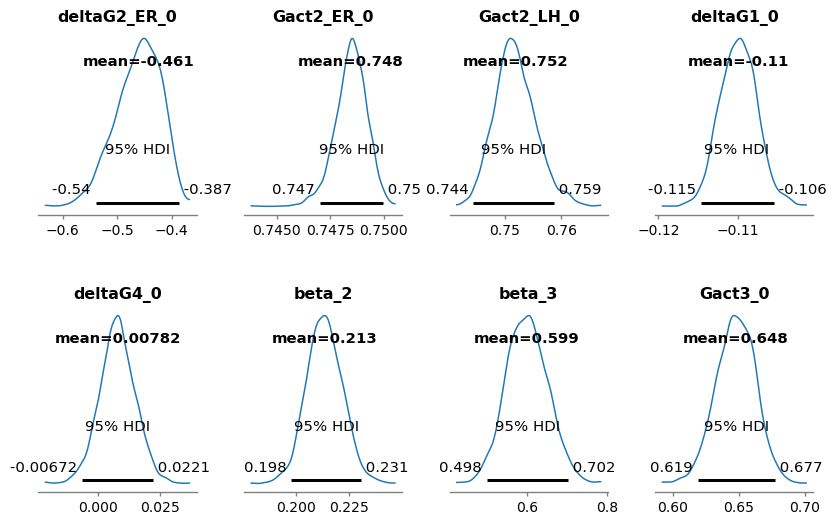

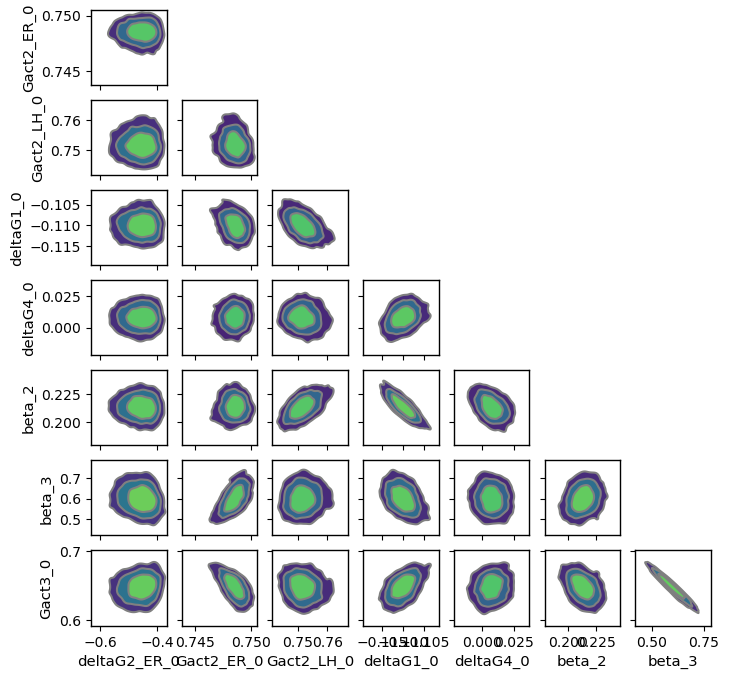

Sampling: [rate]


rate: 0.821


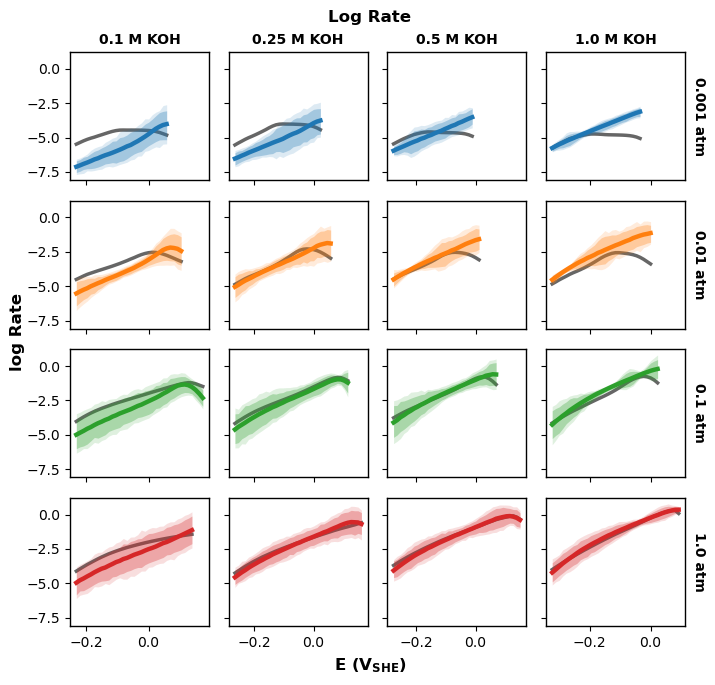

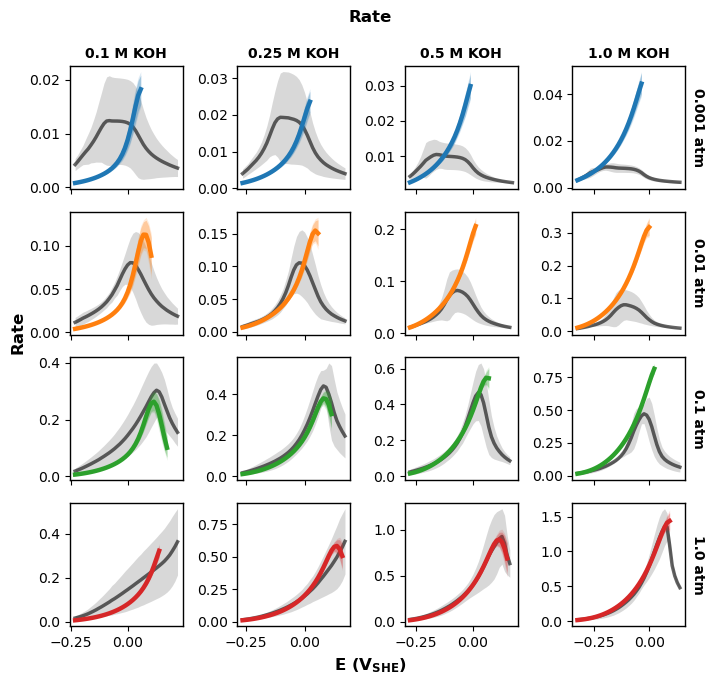

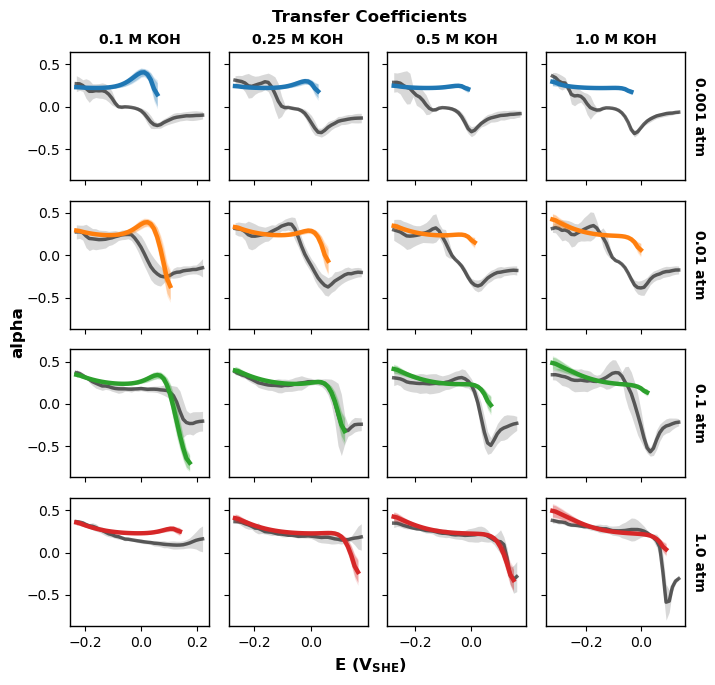

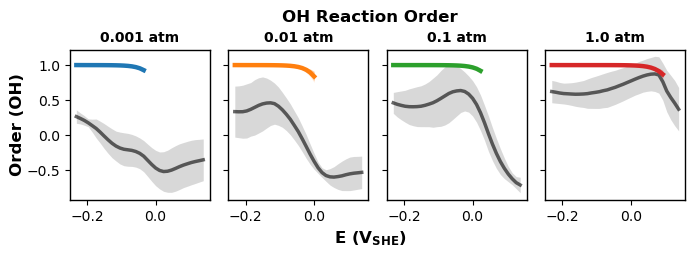

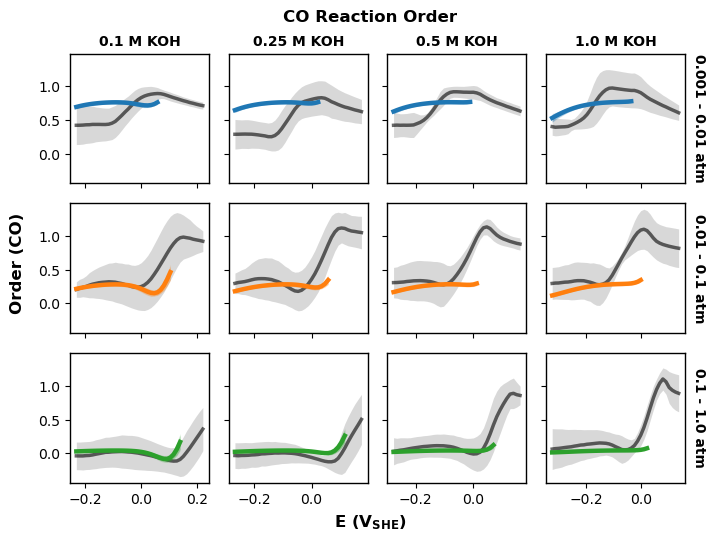

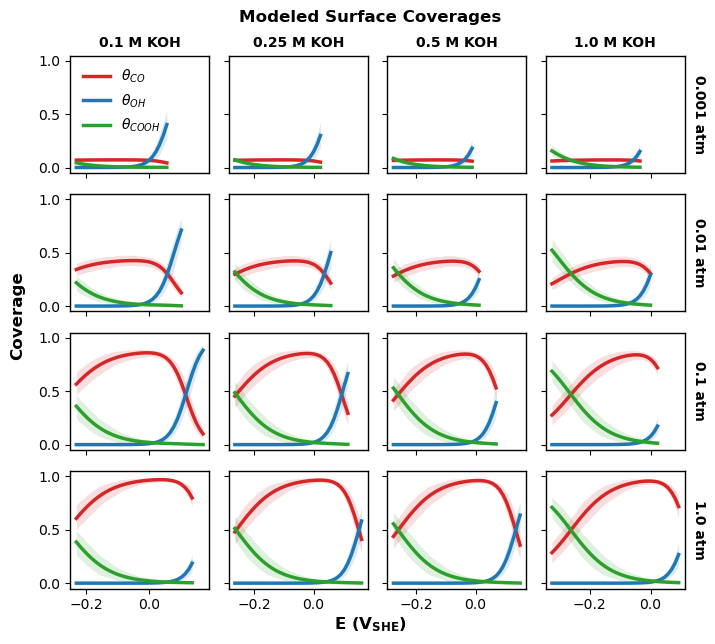

In [7]:
ppc_ER_LH_2_3 = plot_posteriors(trace_ER_LH_2_3, ER_LH_2_3, plot_target)
plot_model_fits(trace_ER_LH_2_3, ppc_ER_LH_2_3); plot_coverages(trace_ER_LH_2_3)

# ER 1 2 3 

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.37,15
,3000,0,0.35,15
,3000,0,0.30,15
,3000,0,0.30,15


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -208.31    18.77
p_loo       11.04        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      494  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



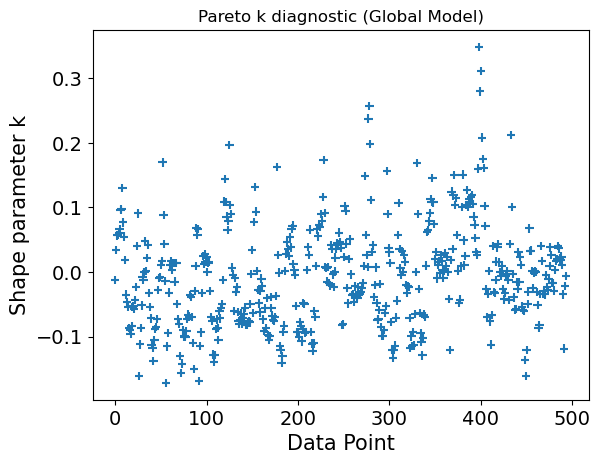

In [8]:
with pm.Model() as ER_1_2_3:
    '''
    1. CO + * <-> CO* (SSA)
    2. CO* + OH- <-> COOH* + (e-) (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (SSA)
    4. OH- + * <-> OH* + (e-) (QEA)
    '''
    # Priors
    deltaG1_0 = pm.TruncatedNormal('deltaG1_0', mu=-0.113, sigma=0.05, upper=0.0)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.09, sigma=0.05) # at 0V_SHE
    deltaG2_ER_0 = pm.Normal('deltaG2_ER_0', mu=-0.457, sigma=0.05) # at 0V_SHE
    beta_2 = pm.TruncatedNormal('beta_2', mu=0.222, sigma=0.02, lower=0.0, upper=1.0)
    beta_3 = pm.TruncatedNormal('beta_3', mu=0.619, sigma=0.05, lower=0.0, upper=1.0)
    Gact1_0 = pm.TruncatedNormal('Gact1_0', mu=0.5, sigma=0.2, lower=0.0) 
    Gact2_0 = pm.Normal('Gact2_0', mu=0.75, sigma=0.02) # at 0V_SHE
    Gact3_0 = pm.Normal('Gact3_0', mu=0.64, sigma=0.02) # at 0V_SHE

    # Thermodynamics
    deltaG1 = deltaG1_0
    deltaG4 = deltaG4_0 - E_in
    deltaG2_ER = deltaG2_ER_0 - E_in
    Gact1 = Gact1_0
    Gact2 = Gact2_0 - beta_2*E_in 
    Gact3 = Gact3_0 - beta_3*E_in  
    
    log_K1 = -deltaG1/(kb_eV*T)
    log_K4 = -deltaG4/(kb_eV*T)
    log_K2_ER = -deltaG2_ER/(kb_eV*T)
    log_k1 = np.log(kb_J*T/h) - Gact1/(kb_eV*T)
    log_k2_ER = np.log(kb_J*T/h) - Gact2/(kb_eV*T)
    log_k3 = np.log(kb_J*T/h) - Gact3/(kb_eV*T)

    log_denom_COOH = pt.logaddexp(log_k2_ER - log_K2_ER, log_k3 + np.log(C_KOH_in))
    log_ratio_COOH_CO = log_k2_ER + np.log(C_KOH_in) - log_denom_COOH
    log_k_eff = log_k3 + np.log(C_KOH_in) + log_ratio_COOH_CO
    log_denom_CO = pt.logaddexp(log_k1 - log_K1, log_k_eff)
    
    term_CO = log_k1 + np.log(P_CO_in) - log_denom_CO
    term_COOH = term_CO + log_ratio_COOH_CO
    term_OH = log_K4 + np.log(C_KOH_in)
    zeros = pt.zeros_like(term_CO)
    log_theta = -pt.logsumexp(pt.stack([zeros, term_CO, term_OH, term_COOH]), axis=0)

    log_theta_CO = term_CO + log_theta
    log_theta_OH = term_OH + log_theta
    log_theta_COOH = term_COOH + log_theta

    theta_CO = pm.Deterministic('theta_CO', pt.exp(log_theta_CO))
    theta_OH = pm.Deterministic('theta_OH', pt.exp(log_theta_OH))
    theta_COOH = pm.Deterministic('theta_COOH', pt.exp(log_theta_COOH))

    # Rate expression 
    log_rate_model = log_k3 + log_theta_COOH + np.log(C_KOH_in)
    log_rate = observables(log_rate_model)  

trace_ER_1_2_3, loo_ER_1_2_3 = fit_and_evaluate(ER_1_2_3)

               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0     0.096  0.012   0.078    0.118      0.000    0.001    2586.0    1716.0    1.0
deltaG2_ER_0 -0.463  0.044  -0.543   -0.380      0.001    0.001    4559.0    3041.0    1.0
Gact2_0       0.744  0.001   0.743    0.746      0.000    0.000    2582.0    2811.0    1.0
Gact3_0       0.646  0.010   0.627    0.664      0.000    0.000     749.0     934.0    1.0
deltaG1_0    -0.248  0.022  -0.292   -0.211      0.000    0.000    4785.0    2755.0    1.0
beta_2        0.220  0.010   0.201    0.239      0.000    0.000    1682.0    2363.0    1.0
beta_3        0.664  0.033   0.603    0.726      0.001    0.001     752.0     961.0    1.0
Gact1_0       0.688  0.001   0.686    0.689      0.000    0.000    4273.0    2781.0    1.0


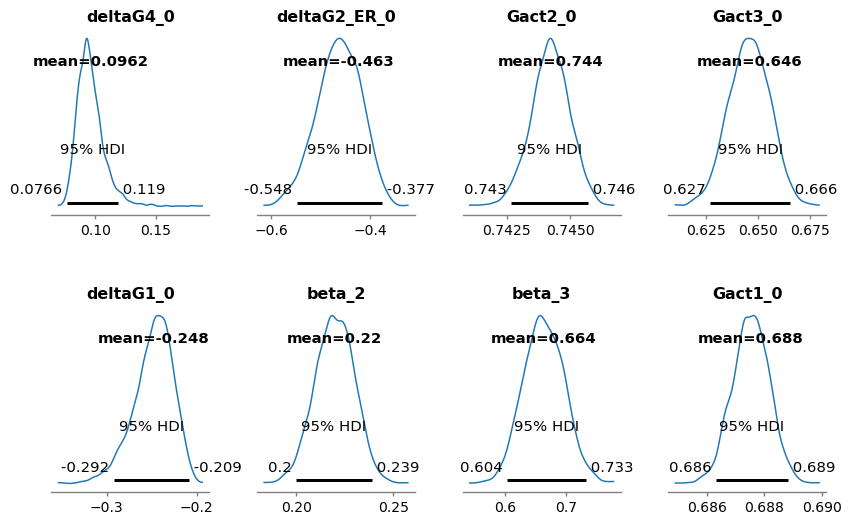

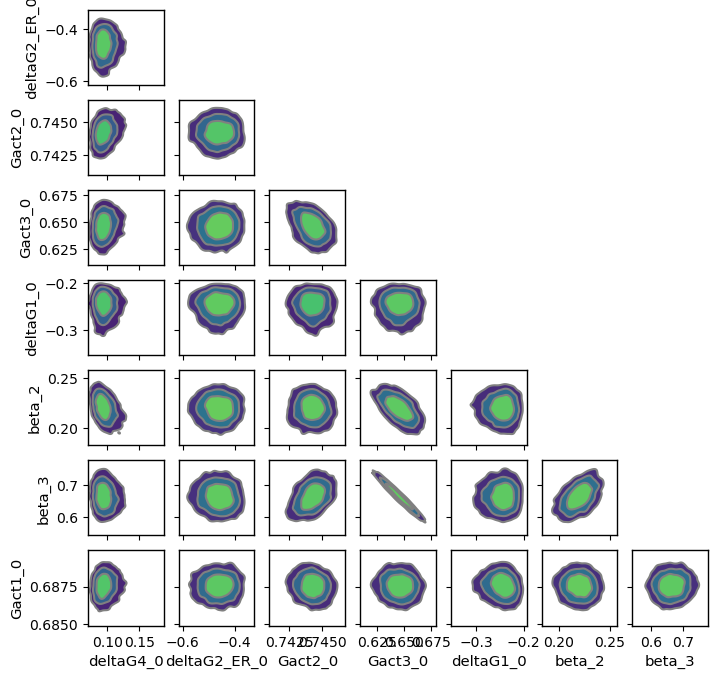

Sampling: [rate]


rate: 0.873


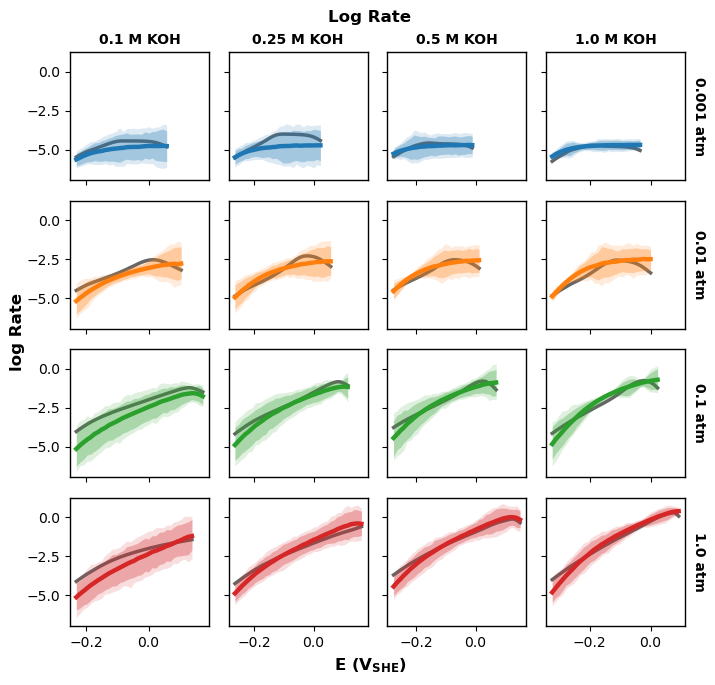

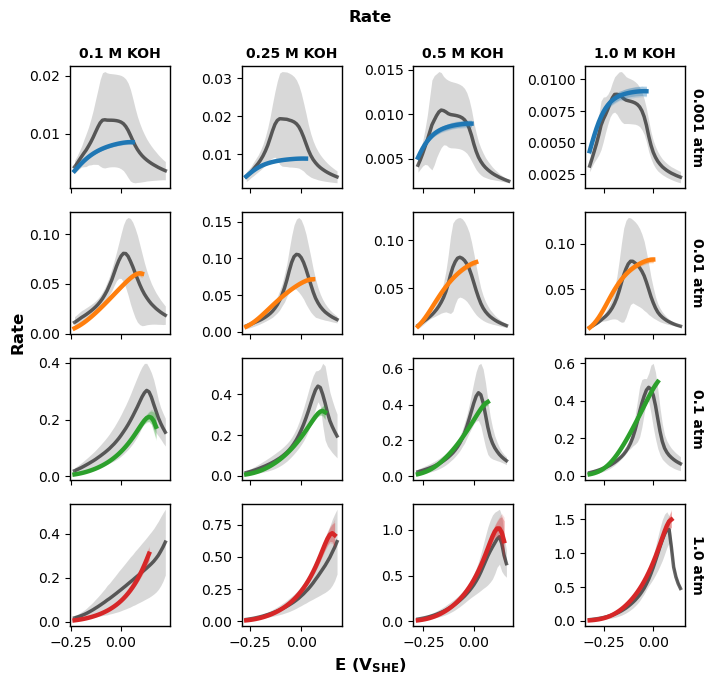

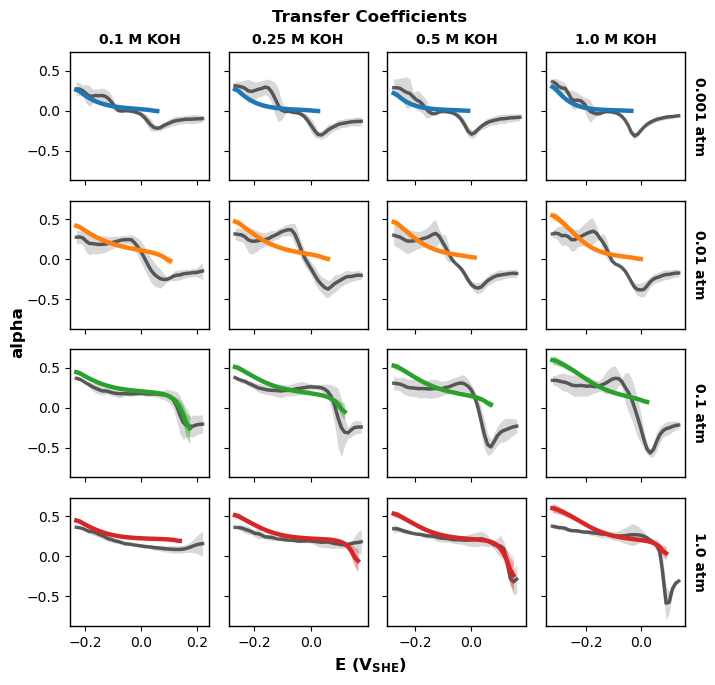

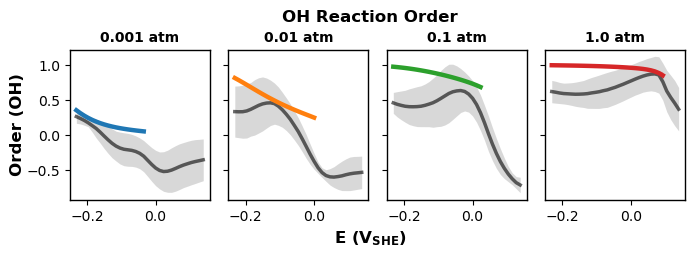

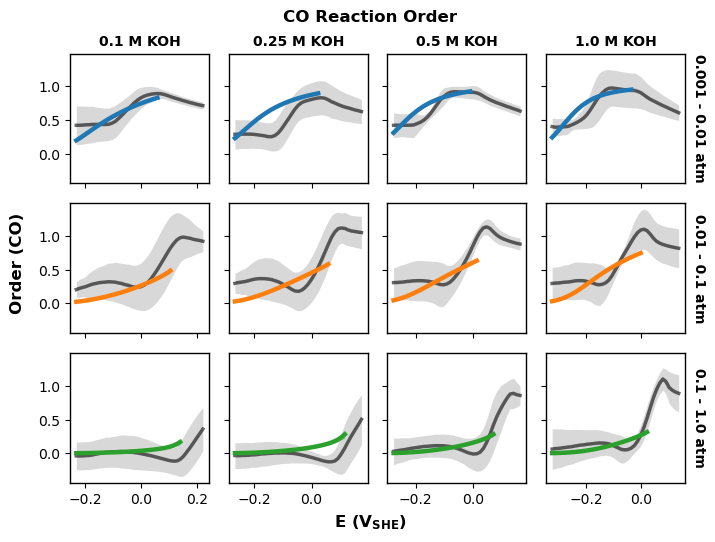

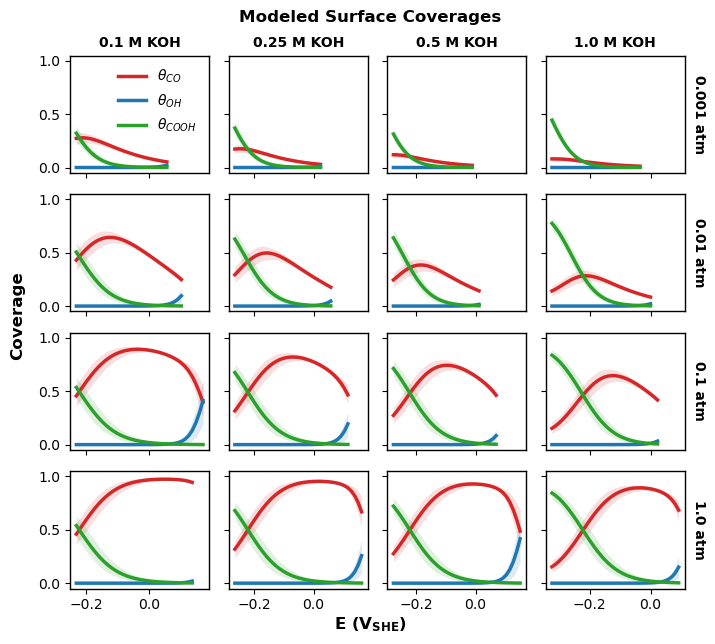

In [9]:
ppc_ER_1_2_3 = plot_posteriors(trace_ER_1_2_3, ER_1_2_3, plot_target)
plot_model_fits(trace_ER_1_2_3, ppc_ER_1_2_3); plot_coverages(trace_ER_1_2_3)

# ER LH 2 3 4

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.12,31
,3000,0,0.12,63
,3000,1,0.12,31
,3000,0,0.12,63


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -406.40    35.02
p_loo       14.92        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      493   99.8%
   (0.70, 1]   (bad)         1    0.2%
   (1, Inf)   (very bad)    0    0.0%



c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\stats\stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


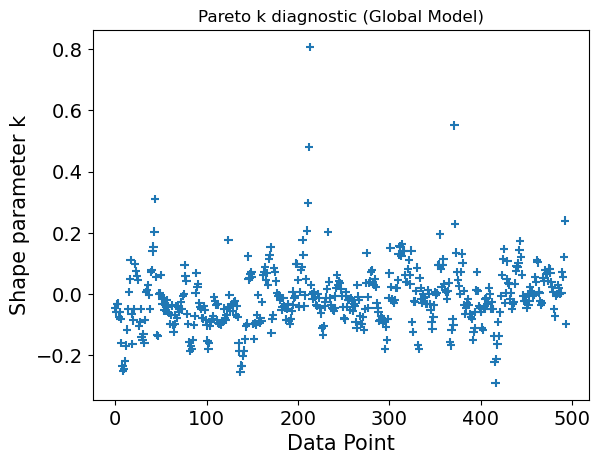

In [14]:
with pm.Model() as ER_LH_2_3_4:
    '''
    1. CO + * <-> CO* (QEA)
    2a. CO* + OH- <-> COOH* + (e-) (SSA)
    2b. CO* + OH* <-> COOH* + * (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Irr) (SSA)
    4. OH- + * <-> OH* + (e-) (SSA)
    '''
    # Priors
    deltaG1_0 = pm.TruncatedNormal('deltaG1_0', mu=-0.11, sigma=0.02, lower=-0.25)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.008, sigma=0.007) # at 0V_SHE
    deltaG2_ER_0 = pm.Normal('deltaG2_ER_0', mu=-0.461, sigma=0.041) # at 0V_SHE
    beta_2 = pm.TruncatedNormal('beta_2', mu=0.213, sigma=0.008, lower=0.0, upper=1.0)
    beta_3 = pm.TruncatedNormal('beta_3', mu=0.599, sigma=0.052, lower=0.0, upper=1.0)
    beta_4 = pm.Beta('beta_4', alpha=5, beta=5)
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.752, sigma=0.004) 
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.748, sigma=0.001) # at 0V_SHE
    Gact3_0 = pm.TruncatedNormal('Gact3_0', mu=0.648, sigma=0.015, lower=0.4) # at 0V_SHE
    Gact4_0 = pm.TruncatedNormal('Gact4_0', mu=0.5, sigma=0.2, lower=0.5) # at 0V_SHE

    # Thermodynamics
    deltaG1 = deltaG1_0
    deltaG2_ER = deltaG2_ER_0 - E_in
    deltaG4 = deltaG4_0 - E_in
    deltaG2_LH = deltaG2_ER_0 - deltaG4_0 # Hess's law
    Gact2_LH = Gact2_LH_0 
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact3 = Gact3_0 - beta_3*E_in
    Gact4 = Gact4_0 - beta_4*E_in

    log_K1 = -deltaG1 / (kb_eV*T)
    log_K2_LH = -deltaG2_LH / (kb_eV*T)
    log_K2_ER = -deltaG2_ER / (kb_eV*T)
    log_K4 = -deltaG4 / (kb_eV*T)

    log_prefactor = np.log(kb_J*T/h)
    log_k2_ER = log_prefactor - Gact2_ER / (kb_eV*T)
    log_k2_LH = log_prefactor - Gact2_LH / (kb_eV*T)
    log_k3 = log_prefactor - Gact3 / (kb_eV*T)
    log_k4 = log_prefactor - Gact4 / (kb_eV*T)

    term_CO = pt.exp(log_K1) * P_CO_in
    R2_ER_f = pt.exp(log_k2_ER) * C_KOH_in
    R2_ER_b = pt.exp(log_k2_ER - log_K2_ER)
    R2_LH_f = pt.exp(log_k2_LH)
    R2_LH_b = pt.exp(log_k2_LH - log_K2_LH)
    R3 = pt.exp(log_k3) * C_KOH_in
    R4_f = pt.exp(log_k4) * C_KOH_in
    R4_b = pt.exp(log_k4 - log_K4)

    # Quadratic solver setup
    c_OH_CO = (R4_f / term_CO + R2_ER_f ) / R4_b 
    c_OH_COOH = -(R2_ER_b + R3) / R4_b
    K_CO = 1/term_CO + 1.0 + c_OH_CO
    K_COOH = 1.0 + c_OH_COOH

    slope_COOH = -K_CO
    int_OH = c_OH_COOH
    slope_OH = c_OH_CO * K_COOH - c_OH_COOH * K_CO
    slope_star = 1/term_CO * K_COOH 

    a_quad = -R2_LH_f * K_COOH * slope_OH + R2_LH_b * slope_COOH * slope_star
    b_quad = (
        -R2_LH_f * K_COOH * int_OH
        + R2_LH_b * (slope_star) - R2_ER_f * (K_COOH ** 2)
        + (R2_ER_b + R3) * K_COOH * slope_COOH)
    c_quad = (R2_ER_b + R3) * K_COOH

    discriminant = b_quad**2.0 - 4.0 * a_quad * c_quad; safe_discriminant = pt.maximum(discriminant, 1e-12)
    b_sign = pt.switch(pt.lt(b_quad, 0.0), -1.0, 1.0)
    q = -0.5 * (b_quad + b_sign * pt.sqrt(safe_discriminant))
    safe_a = pt.switch(pt.eq(a_quad, 0.0), 1e-12, a_quad); safe_q = pt.switch(pt.eq(q, 0.0), 1e-12, q)
    root_1 = q / safe_a; root_2 = c_quad / safe_q
    valid_1 = (root_1 >= -1e-6) & (root_1 <= 1.0 + 1e-6)
    theta_CO_raw = pt.where(valid_1, root_1, root_2)
    safe_K_COOH = pt.switch(pt.eq(K_COOH, 0.0), 1e-12, K_COOH)

    theta_CO   = pm.Deterministic('theta_CO', theta_CO_raw)
    theta_COOH = pm.Deterministic('theta_COOH', (1.0 + slope_COOH * theta_CO) / safe_K_COOH)
    theta_OH   = pm.Deterministic('theta_OH', (int_OH + slope_OH * theta_CO) / safe_K_COOH)

    # Rate expression
    log_rate_model = pt.log(R3 * theta_COOH)
    log_rate = observables(log_rate_model)

trace_ER_LH_2_3_4, loo_ER_LH_2_3_4 = fit_and_evaluate(ER_LH_2_3_4, target_accept=0.99)

               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0    -0.068  0.005  -0.077   -0.059      0.000    0.000    3297.0    3151.0    1.0
deltaG2_ER_0 -0.472  0.034  -0.537   -0.412      0.001    0.001    4303.0    2581.0    1.0
Gact2_LH_0    0.750  0.002   0.747    0.753      0.000    0.000    1893.0    2536.0    1.0
Gact2_ER_0    0.749  0.001   0.748    0.750      0.000    0.000    2526.0    2931.0    1.0
deltaG1_0    -0.104  0.002  -0.107   -0.101      0.000    0.000    1594.0    2302.0    1.0
beta_2        0.196  0.006   0.186    0.207      0.000    0.000    1724.0    2032.0    1.0
beta_3        0.591  0.032   0.531    0.648      0.001    0.001    1199.0    1813.0    1.0
beta_4        0.130  0.051   0.042    0.230      0.001    0.001    3297.0    2589.0    1.0
Gact3_0       0.652  0.009   0.636    0.669      0.000    0.000    1135.0    1486.0    1.0
Gact4_0       0.702  0.005   0.692    0.712      0.000    0.000    2448.0    2371.0    1.0

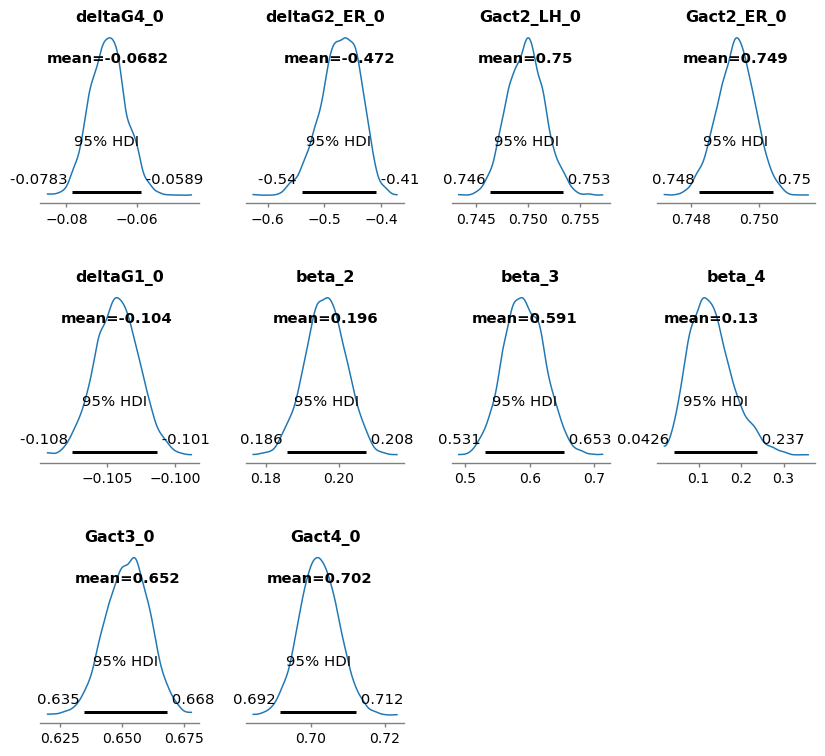

c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\plots\backends\matplotlib\pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


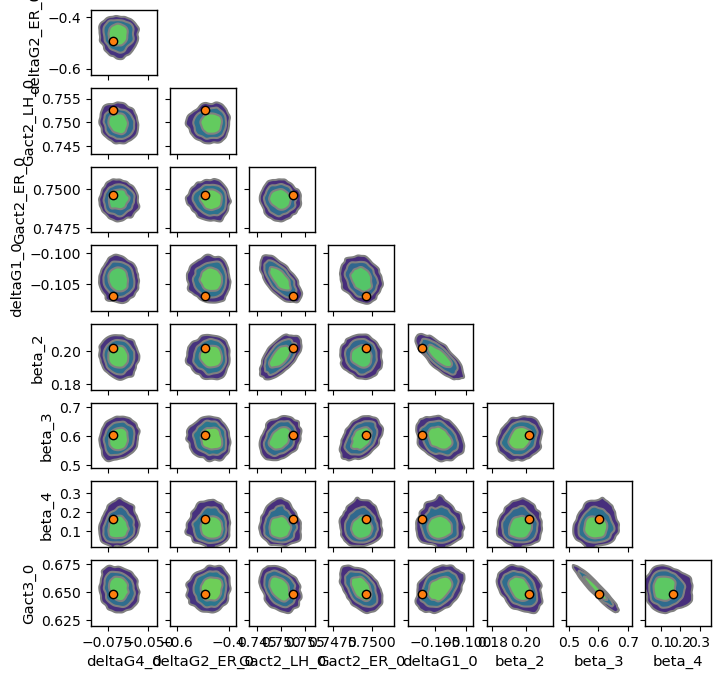

Sampling: [rate]


rate: 0.846


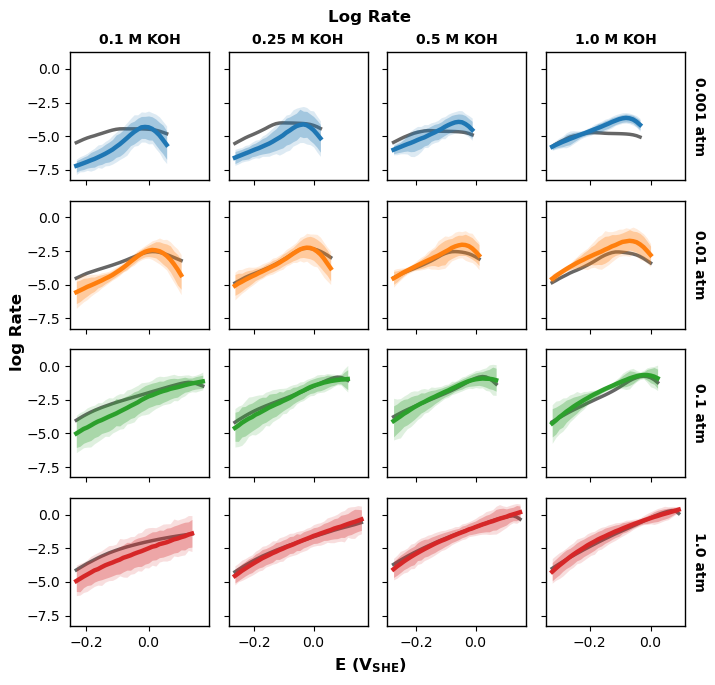

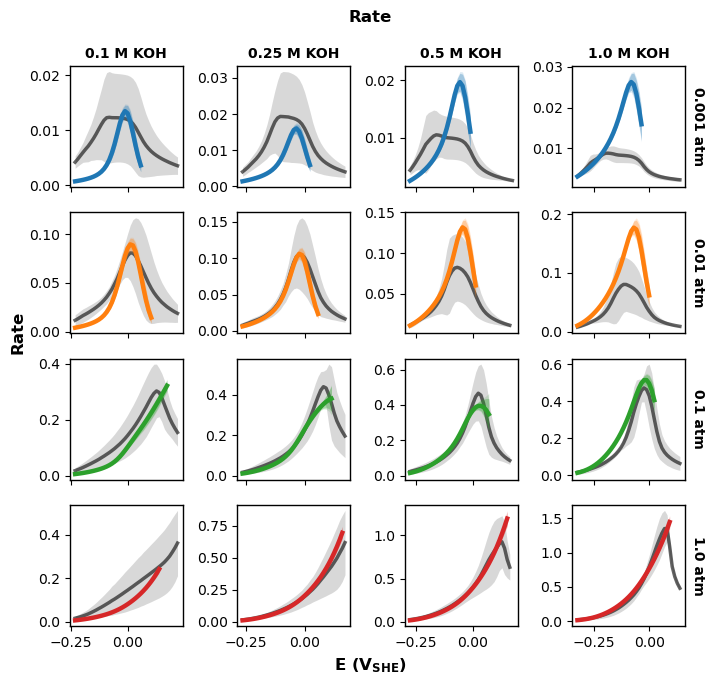

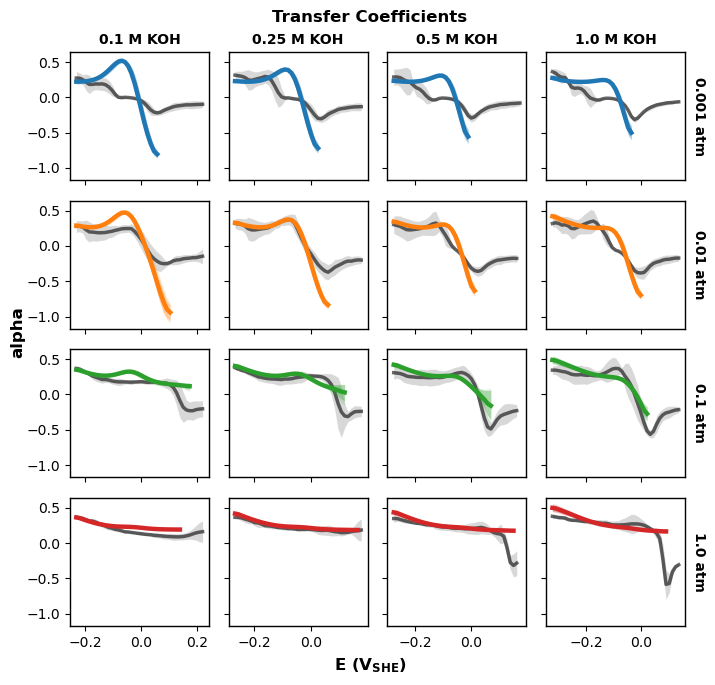

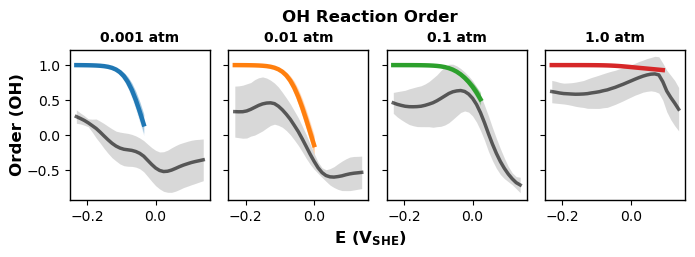

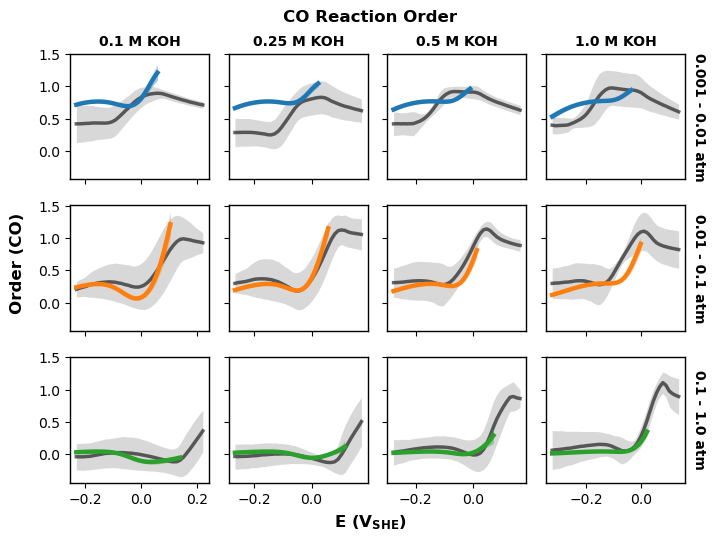

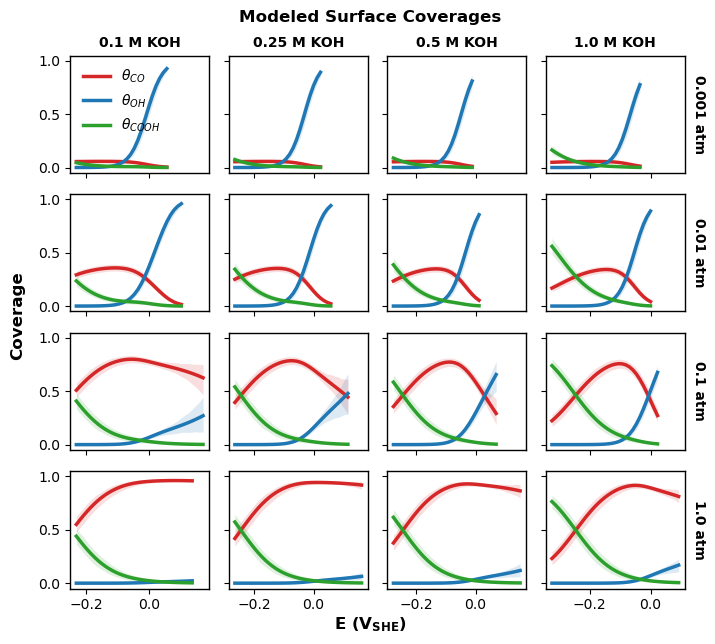

In [15]:
ppc_ER_LH_2_3_4 = plot_posteriors(trace_ER_LH_2_3_4, ER_LH_2_3_4, plot_target)
plot_model_fits(trace_ER_LH_2_3_4, ppc_ER_LH_2_3_4); plot_coverages(trace_ER_LH_2_3_4)

# Full

Progress,Draws,Divergences,Step Size,Gradients/Draw
,3000,0,0.13,31
,3000,0,0.11,31
,3000,0,0.11,31
,3000,0,0.11,63


Computed from 4000 posterior samples and 494 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -152.43    19.60
p_loo       10.62        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      494  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%



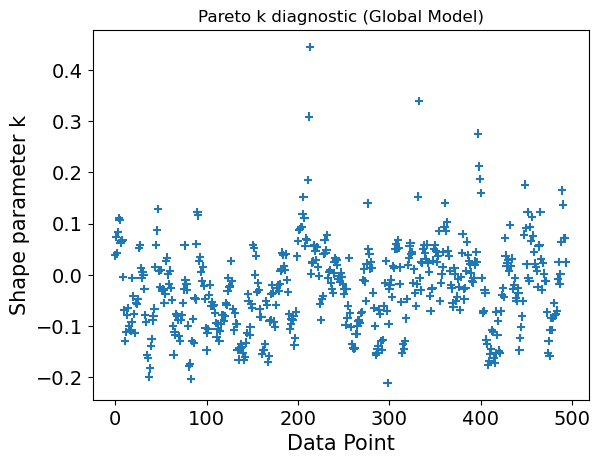

In [17]:
with pm.Model() as full:
    '''
    1. CO + * <-> CO* (SSA)
    2a. CO* + OH- <-> COOH* + (e-) (SSA)
    2b. CO* + OH* <-> COOH* + * (SSA)
    3. COOH* + OH- -> CO2 + H2O + * + (e-) (Irr) (SSA)
    4. OH- + * <-> OH* + (e-) (SSA)
    '''
    # Priors
    deltaG1_0 = pm.TruncatedNormal('deltaG1_0', mu=-0.25, sigma=0.05, upper=0.0)
    deltaG4_0 = pm.Normal('deltaG4_0', mu=0.09, sigma=0.05) # at 0V_SHE
    deltaG2_ER_0 = pm.Normal('deltaG2_ER_0', mu=-0.46, sigma=0.05) # at 0V_SHE
    beta_2 = pm.TruncatedNormal('beta_2', mu=0.22, sigma=0.02, lower=0.0, upper=1.0)
    beta_3 = pm.TruncatedNormal('beta_3', mu=0.66, sigma=0.05, lower=0.0, upper=1.0)
    beta_4 = pm.Beta('beta_4', alpha=5, beta=25)
    Gact1_0 = pm.Normal('Gact1_0', mu=0.688, sigma=0.05)
    Gact2_LH_0 = pm.Normal('Gact2_LH_0', mu=0.752, sigma=0.05) 
    Gact2_ER_0 = pm.Normal('Gact2_ER_0', mu=0.748, sigma=0.02) # at 0V_SHE
    Gact3_0 = pm.TruncatedNormal('Gact3_0', mu=0.648, sigma=0.05, lower=0.0) # at 0V_SHE
    Gact4_0 = pm.TruncatedNormal('Gact4_0', mu=0.702, sigma=0.05, lower=0.0) # at 0V_SHE

    # Thermodynamics
    deltaG1 = deltaG1_0
    deltaG2_ER = deltaG2_ER_0 - E_in
    deltaG4 = deltaG4_0 - E_in
    deltaG2_LH = deltaG2_ER_0 - deltaG4_0 # Hess's law
    Gact1 = Gact1_0
    Gact2_LH = Gact2_LH_0 
    Gact2_ER = Gact2_ER_0 - beta_2*E_in
    Gact3 = Gact3_0 - beta_3*E_in
    Gact4 = Gact4_0 - beta_4*E_in

    log_K1 = -deltaG1 / (kb_eV*T)
    log_K2_LH = -deltaG2_LH / (kb_eV*T)
    log_K2_ER = -deltaG2_ER / (kb_eV*T)
    log_K4 = -deltaG4 / (kb_eV*T)

    log_prefactor = np.log(kb_J*T/h)
    log_k1 = log_prefactor - Gact1 / (kb_eV*T)
    log_k2_ER = log_prefactor - Gact2_ER / (kb_eV*T)
    log_k2_LH = log_prefactor - Gact2_LH / (kb_eV*T)
    log_k3 = log_prefactor - Gact3 / (kb_eV*T)
    log_k4 = log_prefactor - Gact4 / (kb_eV*T)

    R1_f = pt.exp(log_k1) * P_CO_in
    R1_b = pt.exp(log_k1 - log_K1)
    R2_ER_f = pt.exp(log_k2_ER) * C_KOH_in
    R2_ER_b = pt.exp(log_k2_ER - log_K2_ER)
    R2_LH_f = pt.exp(log_k2_LH)
    R2_LH_b = pt.exp(log_k2_LH - log_K2_LH)
    R3 = pt.exp(log_k3) * C_KOH_in
    R4_f = pt.exp(log_k4) * C_KOH_in
    R4_b = pt.exp(log_k4 - log_K4)

    # Quadratic solver setup
    c_star_CO = R1_b / R1_f
    c_star_COOH = R3 / R1_f 
    c_OH_CO = (R4_f * c_star_CO + R2_ER_f ) / R4_b 
    c_OH_COOH = (R4_f * c_star_COOH - R2_ER_b - R3) / R4_b
    K_CO = c_star_CO + 1.0 + c_OH_CO
    K_COOH = c_star_COOH + 1.0 + c_OH_COOH

    slope_COOH = -K_CO
    int_OH = c_OH_COOH
    slope_OH = c_OH_CO * K_COOH - c_OH_COOH * K_CO
    int_star = c_star_COOH
    slope_star = c_star_CO * K_COOH + c_star_COOH * slope_COOH

    a_quad = -R2_LH_f * K_COOH * slope_OH + R2_LH_b * slope_COOH * slope_star
    b_quad = (
        -R2_LH_f * K_COOH * int_OH
        + R2_LH_b * (slope_star + int_star * slope_COOH)
        - R2_ER_f * (K_COOH ** 2)
        + (R2_ER_b + R3) * K_COOH * slope_COOH
    )
    c_quad = (R2_ER_b + R3) * K_COOH + R2_LH_b * int_star

    discriminant = b_quad**2.0 - 4.0 * a_quad * c_quad; safe_discriminant = pt.maximum(discriminant, 1e-12)
    b_sign = pt.switch(pt.lt(b_quad, 0.0), -1.0, 1.0)
    q = -0.5 * (b_quad + b_sign * pt.sqrt(safe_discriminant))
    safe_a = pt.switch(pt.eq(a_quad, 0.0), 1e-12, a_quad)
    safe_q = pt.switch(pt.eq(q, 0.0), 1e-12, q)
    root_1 = q / safe_a; root_2 = c_quad / safe_q
    valid_1 = (root_1 >= -1e-6) & (root_1 <= 1.0 + 1e-6)
    theta_CO_raw = pt.where(valid_1, root_1, root_2)
    safe_K_COOH = pt.switch(pt.eq(K_COOH, 0.0), 1e-12, K_COOH)

    theta_CO   = pm.Deterministic('theta_CO', theta_CO_raw)
    theta_COOH = pm.Deterministic('theta_COOH', (1.0 + slope_COOH * theta_CO) / safe_K_COOH)
    theta_OH   = pm.Deterministic('theta_OH', (int_OH + slope_OH * theta_CO) / safe_K_COOH)

    # Rate expression
    log_rate_model = pt.log(R3 * theta_COOH)
    log_rate = observables(log_rate_model)

trace_full, loo_full = fit_and_evaluate(full, target_accept=0.99)

               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  r_hat
deltaG4_0     0.002  0.005  -0.006    0.012      0.000    0.000    2925.0    2635.0    1.0
deltaG2_ER_0 -0.469  0.043  -0.552   -0.391      0.001    0.001    5111.0    2862.0    1.0
Gact1_0       0.688  0.001   0.687    0.689      0.000    0.000    3299.0    2932.0    1.0
Gact2_LH_0    0.696  0.005   0.687    0.706      0.000    0.000    2643.0    2390.0    1.0
Gact2_ER_0    0.750  0.001   0.748    0.751      0.000    0.000    2602.0    2694.0    1.0
deltaG1_0    -0.285  0.036  -0.353   -0.222      0.000    0.001    6384.0    3029.0    1.0
beta_2        0.190  0.009   0.173    0.207      0.000    0.000    1920.0    2762.0    1.0
beta_3        0.691  0.034   0.629    0.754      0.001    0.001     872.0    1391.0    1.0
beta_4        0.097  0.033   0.035    0.156      0.001    0.000    2370.0    1941.0    1.0
Gact3_0       0.639  0.010   0.621    0.658      0.000    0.000     851.0    1245.0    1.0

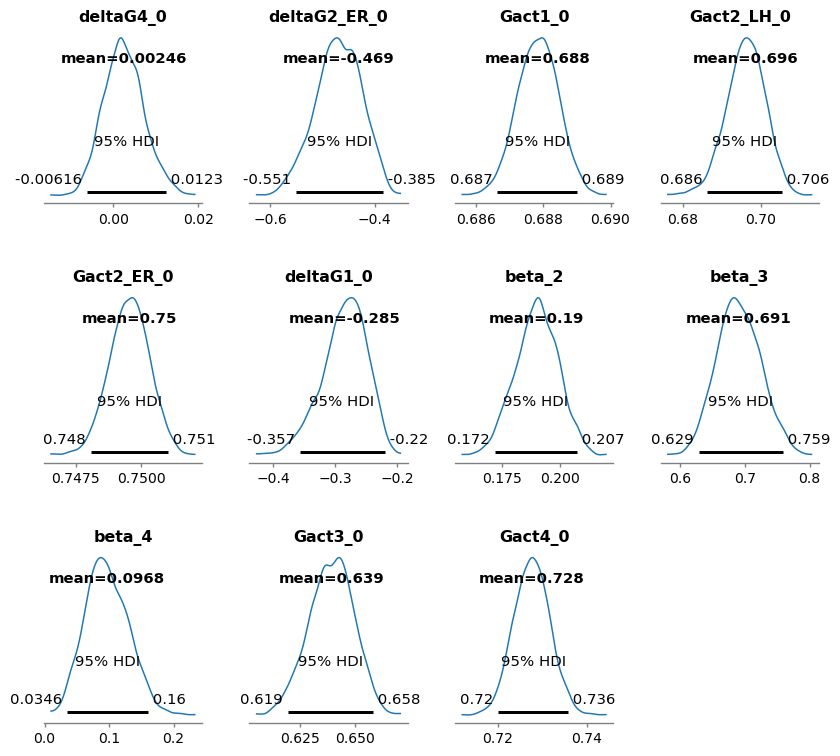

c:\Users\awast\miniconda3\envs\jdftx_env\Lib\site-packages\arviz\plots\backends\matplotlib\pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


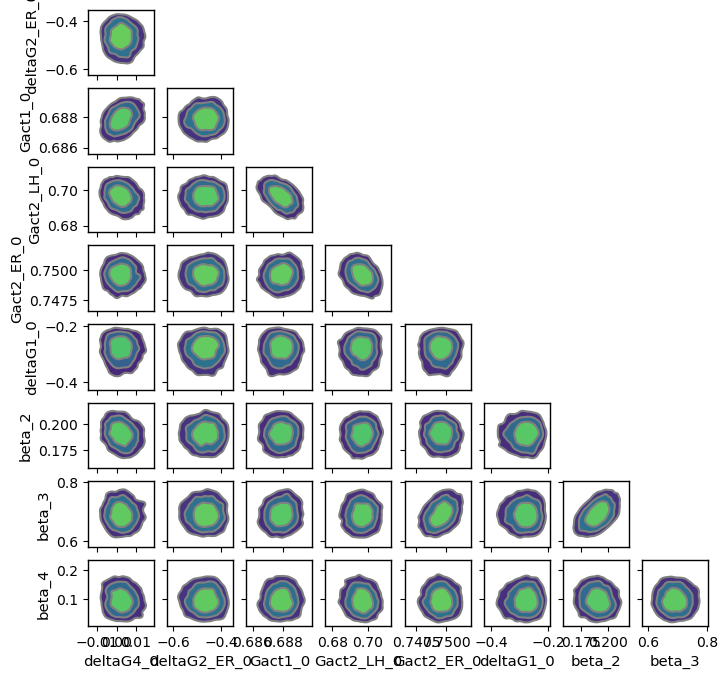

Sampling: [rate]


rate: 0.875


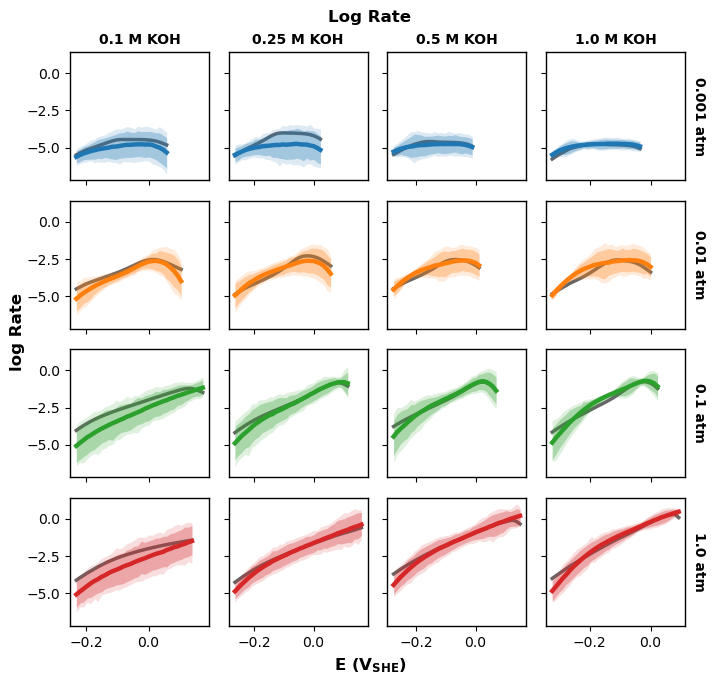

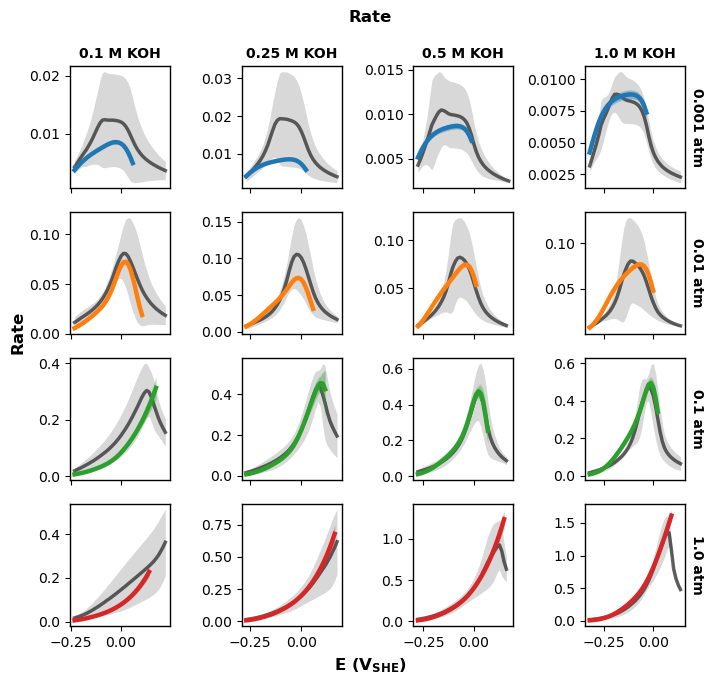

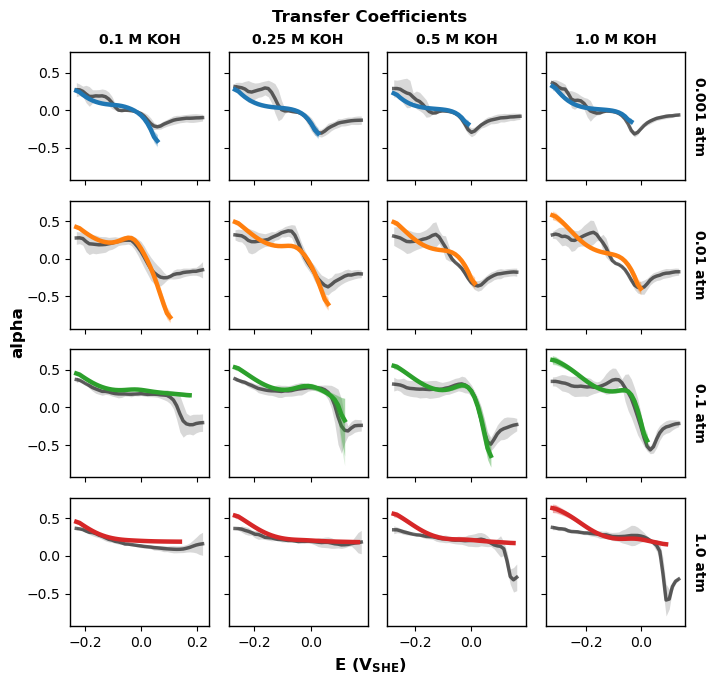

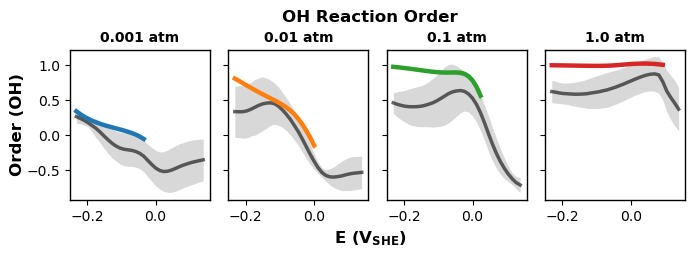

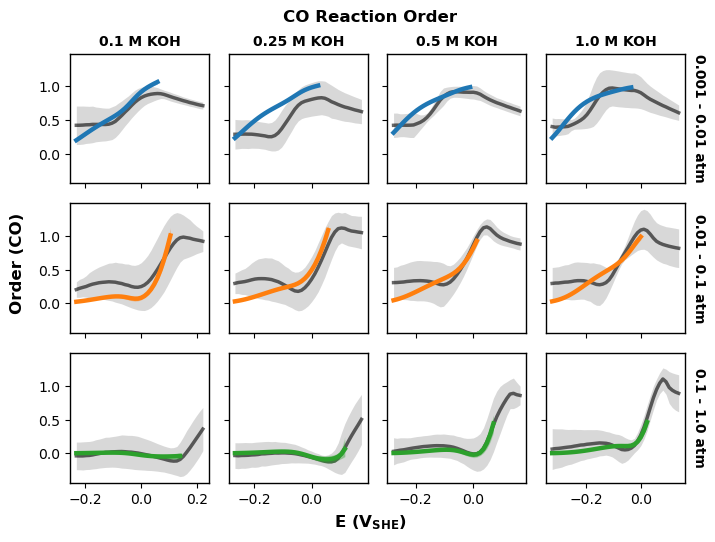

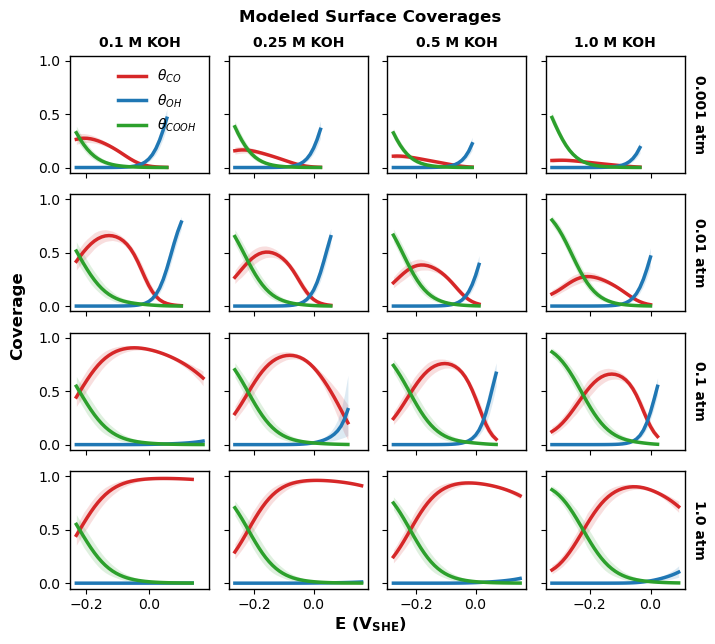

In [18]:
ppc_full = plot_posteriors(trace_full, full, plot_target)
plot_model_fits(trace_full, ppc_full); plot_coverages(trace_full)

# Comparison

             rank    elpd_loo      p_loo   elpd_diff        weight         se        dse  warning scale
full            0 -152.430738  10.615849    0.000000  8.744867e-01  19.603510   0.000000    False   log
ER_1_2_3        1 -208.307119  11.044517   55.876380  2.984113e-12  18.774922   9.678263    False   log
ER_LH_2_3_4     2 -406.401031  14.916418  253.970292  1.255133e-01  35.015776  34.872914     True   log
ER_LH_2_3       3 -529.724457  16.863999  377.293718  0.000000e+00  38.348027  38.786402    False   log


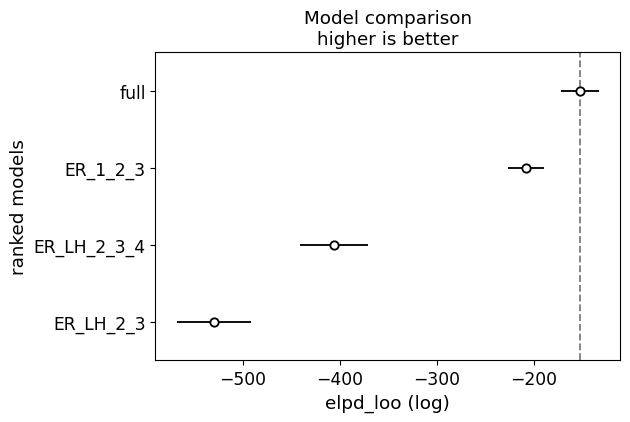

In [19]:
comparison_dict = {
    "ER_LH_2_3": loo_ER_LH_2_3,
    "ER_1_2_3": loo_ER_1_2_3,
    "ER_LH_2_3_4": loo_ER_LH_2_3_4,
    "full": loo_full,
}

comp_df = az.compare(comparison_dict, ic="loo", method="stacking")
print(comp_df)
az.plot_compare(comp_df, insample_dev=False)
plt.show()

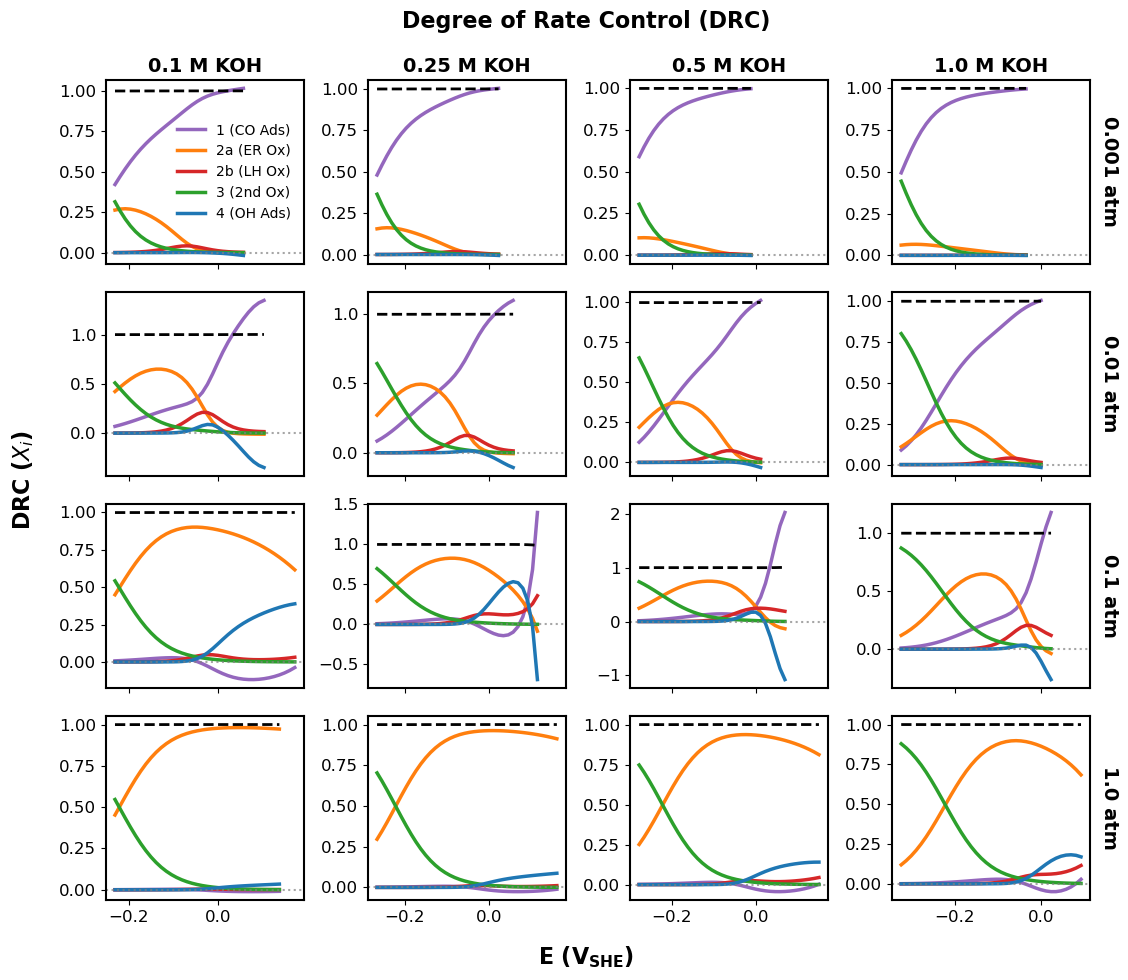

In [22]:
from scipy.optimize import fsolve

kB_eV = 8.617333262145e-5  # eV/K
h_eV_s = 4.135667696e-15   # eV*s
T = 298.15
kT = kB_eV * T
kT_h = kT / h_eV_s

# Posterior means from the `full` model
params = {
    'deltaG4_0': 0.002,
    'deltaG2_ER_0': -0.469,
    'Gact1_0': 0.688,
    'Gact2_LH_0': 0.696,
    'Gact2_ER_0': 0.750,
    'deltaG1_0': -0.285,
    'beta_2': 0.190,
    'beta_3': 0.691,
    'beta_4': 0.097,
    'Gact3_0': 0.639,
    'Gact4_0': 0.728
}

# =============================================================================
# 2. Rate Constant & Steady-State Solvers
# =============================================================================
def get_rate_constants(E, C_KOH, P_CO, p, perturb_step=None, epsilon=1e-3):
    """Calculates all k_f and k_b. Applies a (1+epsilon) perturbation if specified."""
    k = {}
    
    # Step 1: CO + * <-> CO*
    k['1f'] = kT_h * np.exp(-p['Gact1_0'] / kT) * P_CO
    k['1b'] = kT_h * np.exp(-(p['Gact1_0'] - p['deltaG1_0']) / kT)
    
    # Step 4: OH- + * <-> OH* + e-
    k['4f'] = kT_h * np.exp(-(p['Gact4_0'] - p['beta_4'] * E) / kT) * C_KOH
    k['4b'] = kT_h * np.exp(-(p['Gact4_0'] - p['deltaG4_0'] + (1 - p['beta_4']) * E) / kT)
    
    # Step 2a (ER): CO* + OH- <-> COOH* + e-
    k['2af'] = kT_h * np.exp(-(p['Gact2_ER_0'] - p['beta_2'] * E) / kT) * C_KOH
    k['2ab'] = kT_h * np.exp(-(p['Gact2_ER_0'] - p['deltaG2_ER_0'] + (1 - p['beta_2']) * E) / kT)
    
    # Step 2b (LH): CO* + OH* <-> COOH* + * # Thermodynamics: dG_2LH = dG_2ER - dG_4. No electron transfer = no E dependence.
    dG_2LH = p['deltaG2_ER_0'] - p['deltaG4_0']
    k['2bf'] = kT_h * np.exp(-p['Gact2_LH_0'] / kT)
    k['2bb'] = kT_h * np.exp(-(p['Gact2_LH_0'] - dG_2LH) / kT)
    
    # Step 3 (Irr): COOH* + OH- -> CO2 + H2O + * + e-
    k['3f'] = kT_h * np.exp(-(p['Gact3_0'] - p['beta_3'] * E) / kT) * C_KOH
    
    # Apply perturbation for DRC calculation
    if perturb_step == '1':
        k['1f'] *= (1 + epsilon); k['1b'] *= (1 + epsilon)
    elif perturb_step == '2a':
        k['2af'] *= (1 + epsilon); k['2ab'] *= (1 + epsilon)
    elif perturb_step == '2b':
        k['2bf'] *= (1 + epsilon); k['2bb'] *= (1 + epsilon)
    elif perturb_step == '3':
        k['3f'] *= (1 + epsilon)
    elif perturb_step == '4':
        k['4f'] *= (1 + epsilon); k['4b'] *= (1 + epsilon)
        
    return k

def steady_state_residuals(theta, k):
    th_CO, th_OH, th_COOH = theta
    th_star = 1.0 - th_CO - th_OH - th_COOH
    
    r1 = k['1f'] * th_star - k['1b'] * th_CO
    r4 = k['4f'] * th_star - k['4b'] * th_OH
    r2a = k['2af'] * th_CO - k['2ab'] * th_COOH
    r2b = k['2bf'] * th_CO * th_OH - k['2bb'] * th_COOH * th_star
    r3 = k['3f'] * th_COOH
    
    dCO_dt = r1 - r2a - r2b
    dOH_dt = r4 - r2b
    dCOOH_dt = r2a + r2b - r3
    
    return [dCO_dt, dOH_dt, dCOOH_dt]

def solve_rate(E, C_KOH, P_CO, p, perturb_step=None, epsilon=1e-3, guess=[0.5, 0.1, 0.01]):
    k = get_rate_constants(E, C_KOH, P_CO, p, perturb_step, epsilon)
    theta_opt, infodict, ier, mesg = fsolve(steady_state_residuals, guess, args=(k,), full_output=True)
    
    # Enforce physical bounds in case of numerical drift
    th_CO, th_OH, th_COOH = np.clip(theta_opt, 0, 1)
    rate = k['3f'] * th_COOH
    return rate, [th_CO, th_OH, th_COOH]

# =============================================================================
# 3. Calculate DRCs Across the Grid
# =============================================================================
steps = ['1', '2a', '2b', '3', '4']
epsilon = 1e-3
drc_results = {}

for C in C_KOH_list:
    for P in P_CO_list:
        E_array = experiments_interp[(C, P)]['E']
        drc_grid = {step: np.zeros(len(E_array)) for step in steps}
        
        guess = [0.5, 0.1, 0.01] # Initial guess for coverages
        
        for i, E in enumerate(E_array):
            # Calculate Base Rate
            r_base, guess = solve_rate(E, C, P, params, guess=guess)
            
            # Calculate Perturbed Rates and DRC
            for step in steps:
                r_pert, _ = solve_rate(E, C, P, params, perturb_step=step, epsilon=epsilon, guess=guess)
                # DRC = d(ln r) / d(ln k) ~ (r_pert - r_base) / (r_base * epsilon)
                drc_grid[step][i] = (r_pert - r_base) / (r_base * epsilon)
                
        drc_results[(C, P)] = (E_array, drc_grid)

# =============================================================================
# 4. Plotting DRCs (4x4 Grid)
# =============================================================================
# Increased plot size and updated font sizes for better visibility
plt.rcParams.update({'font.size': 12, 'axes.linewidth': 1.5, 'lines.linewidth': 2})
figsize = (12, 10) 
title_size, label_size = 16, 14

# Set sharey=False for independent y-axes
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=figsize, sharex='col', sharey=False)    
fig.suptitle('Degree of Rate Control (DRC)', fontsize=title_size, fontweight='bold', y=0.97)
fig.supxlabel(r"E (V$_{\mathbf{SHE}}$)", fontweight='bold', fontsize=label_size+2)
fig.supylabel(r"DRC ($X_i$)", fontweight='bold', fontsize=label_size+2)

colors = {'1': 'tab:purple', '2a': 'tab:orange', '2b': 'tab:red', '3': 'tab:green', '4': 'tab:blue'}
labels = {'1': '1 (CO Ads)', '2a': '2a (ER Ox)', '2b': '2b (LH Ox)', '3': '3 (2nd Ox)', '4': '4 (OH Ads)'}

for i, C_KOH in enumerate(C_KOH_list):
    for j, P_CO in enumerate(P_CO_list):
        ax = axes[j, i]
        E_array, drc_grid = drc_results[(C_KOH, P_CO)]
        
        # Plot individual step DRCs
        for step in steps:
            ax.plot(E_array, drc_grid[step], color=colors[step], label=labels[step], lw=2.5)
            
        # Calculate and plot the sum of DRCs
        sum_drc = np.sum([drc_grid[step] for step in steps], axis=0)
        ax.plot(E_array, sum_drc, color='black', linestyle='--', lw=2.0, zorder=10)
        
        # Zero-line reference (changed to dotted gray so it doesn't clash with the sum line)
        ax.axhline(0, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
        
        # Titles and labels
        if j == 0: ax.set_title(f'{C_KOH} M KOH', fontsize=label_size, fontweight='bold')
        if i == 3: ax.text(1.05, 0.5, f'{P_CO} atm', transform=ax.transAxes, rotation=-90, va='center', fontsize=label_size, fontweight='bold')
        if i == 0 and j == 0: 
            ax.legend(loc='best', frameon=False, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(right=0.92, top=0.90, bottom=0.08, left=0.10) 
plt.show()
plt.rcParams.update(plt.rcParamsDefault)